In [65]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ERCAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ERCAN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ERCAN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [67]:
# Orijinal veri
df = pd.read_csv("train.csv")

# 5 000 satırlık rastgele alt küme
df_sample = df.sample(n=5000, random_state=42)

# Yeni dosyayı kaydet
df_sample.to_csv("train_sample_5000.csv", index=False)

print("Oluşturulan alt küme satır sayısı:", df_sample.shape[0])

# Yeni oluşturduğumuz alt küme dosyasını yükle
df_sample = pd.read_csv("train_sample_5000.csv")


# Veriyi incele
print(df_sample.head())


Oluşturulan alt küme satır sayısı: 5000
         posting_id                                 image       image_phash  \
0  train_3994562790  8c79f5e57737e712428b009f3b811b29.jpg  f5c972349712386d   
1  train_2721383565  5dc0a645807ec85ba540e39ee7a1db04.jpg  b939c692c34e9867   
2   train_161578771  e4647b784f847e807173e9329c748636.jpg  bbb84c822c86e767   
3   train_481272730  9bf9a36b8a4f81ee1f4a0b463799e5b3.jpg  8af3f7809c5b0ce1   
4  train_2554398684  5c138e8fccfc7bc6d6e364bd31eb6657.jpg  9b7ae0c595b38307   

                                                                                  title  \
0                             Creamer Nabati (Non Dairy Creamer) Premium & Reguler 1 Kg   
1                                      Chek Hup 3 in 1 Ipoh White Coffee King 40gr x 15   
2  ( 27AN.ID) COD Kacamata Hitam KM50 Gaya Steampunk Vintage Bentuk Kotak Gaya Harajuku   
3                                             Sapu Mini + Cikrak Sebaguna (Paket Hemat)   
4                             

In [69]:
df_sample = pd.read_csv("train_sample_5000.csv")

# 'title sutunuyla çalışıyoruz
sentences = df_sample['title'].astype(str).tolist()



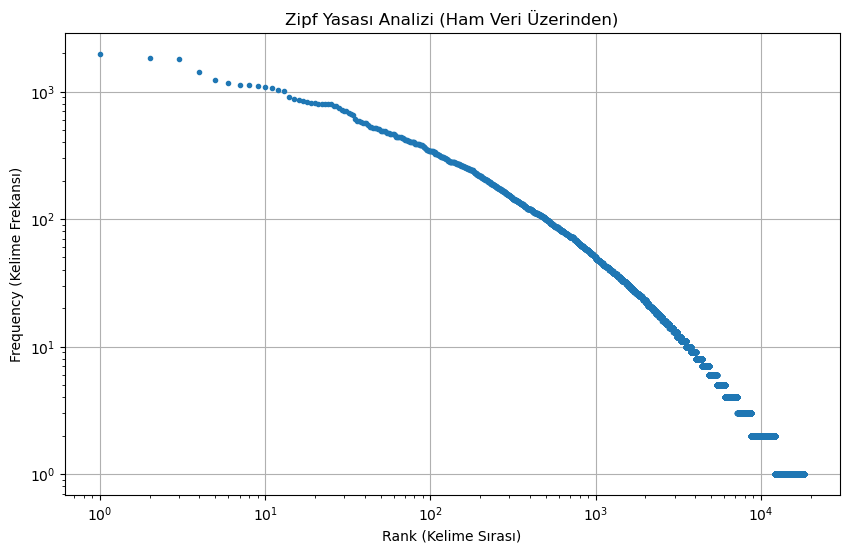

In [71]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np


# Veriyi yükle (train.csv dosyanız aynı klasörde olmalı)
df_sample = pd.read_csv('train_sample_5000.csv')

# Ham başlıkları tek bir metin haline getir
all_text = ' '.join(df['title'].astype(str))

# Kelimelere ayır (tokenize) ve küçük harfe çevir, sadece harf olanları al
tokens = [word.lower() for word in word_tokenize(all_text) if word.isalpha()]

# Kelime frekanslarını hesapla
word_counts = Counter(tokens)

# Sıklıklara göre sırala
sorted_word_counts = word_counts.most_common()

# Rank (sıra) ve frekans değerlerini çıkar
ranks = np.arange(1, len(sorted_word_counts) + 1)
frequencies = [count for word, count in sorted_word_counts]

# Zipf Yasası grafiği (log-log eksende)
plt.figure(figsize=(10,6))
plt.loglog(ranks, frequencies, marker='.', linestyle='None')
plt.title("Zipf Yasası Analizi (Ham Veri Üzerinden)")
plt.xlabel("Rank (Kelime Sırası)")
plt.ylabel("Frequency (Kelime Frekansı)")
plt.grid(True)
plt.show()


In [72]:
import re

# Örnek marka listesi — gerekirse genişletilebilir
brands = ['nike', 'adidas', 'samsung', 'apple', 'xiaomi', 'huawei']

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = text.lower()  # Lowercase (küçük harfe dönüştür)
    
    # HTML taglerini temizle
    text = re.sub(r'<[^>]+_>', '', text)
    
    # Marka isimlerini kaldır (önce brands listesi tanımlanmış olmalı)
    # Burada sadece listeyi kullanıyoruz ve listede yer alan markaları tamamen temizliyoruz
    text = re.sub(r'(' + '|'.join(map(re.escape, brands)) + r')', '', text)

    # Fiyat ifadelerini kaldır (USD, GBP, EUR, $, £, €)
    text = re.sub(r'\d+(?:\.\d+)?\s?(usd|gbp|eur|\$|£|€)', '', text)
    
    # Ölçü birimlerini kaldır (pound, oz, lb, ml, l, g, mg, inch, in, cm, mm)
    text = re.sub(r'\d+(?:\.\d+)?\s?(pounds?|lbs?|oz|ml|l|g|gr|x|kg|mg|inch|in|cm|mm)', '', text)

    # Kalan tüm sayıları temizle
    text = re.sub(r'\d+', '', text)
    
    # Noktalama işaretlerini kaldır (sadece harf ve rakamlar kalsın)
    text = re.sub(r'[^\w\s]', '', text)
    
    # Fazla boşlukları temizle ve başındaki/sonundaki boşlukları kaldır
    text = re.sub(r'\s+', ' ', text).strip()
 
    return text






In [75]:
# Lemmatizer başlat
lemmatizer = WordNetLemmatizer()

# POS etiketlerini WordNet formatına dönüştüren fonksiyon
def get_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ     # Sıfat
    elif tag.startswith('V'): return wordnet.VERB  # Fiil
    elif tag.startswith('R'): return wordnet.ADV   # Zarf
    else: return wordnet.NOUN                      # İsim (varsayılan)

# Lemmatizasyon yapan fonksiyon
def lemmatize_text(text):
    tokens = word_tokenize(text)                  # Kelimelere ayır
    tags = pos_tag(tokens)                        # Her kelimeye tür etiketi ata
    return " ".join([lemmatizer.lemmatize(w, get_pos(t)) for w, t in tags])  # Lemmatize et

# CSV dosyasını oku
df_sample = pd.read_csv("train_sample_5000.csv")

# Temizlenmiş ve kök hâline getirilmiş başlıkları ekle
df_sample["cleaned_title"] = df_sample["title"].astype(str).apply(clean_text)
df_sample["lemmatized_title"] = df_sample["cleaned_title"].apply(lemmatize_text)

# Sonuçları kontrol etmek için ilk 5 satırı yazdır
print(df_sample[["title", "cleaned_title", "lemmatized_title"]].head())

                                                                                  title  \
0                             Creamer Nabati (Non Dairy Creamer) Premium & Reguler 1 Kg   
1                                      Chek Hup 3 in 1 Ipoh White Coffee King 40gr x 15   
2  ( 27AN.ID) COD Kacamata Hitam KM50 Gaya Steampunk Vintage Bentuk Kotak Gaya Harajuku   
3                                             Sapu Mini + Cikrak Sebaguna (Paket Hemat)   
4                               SARUNG TANGAN IGLOVE TOUCH SCREEN HP ANDROID GOJEK GRAB   

                                                                cleaned_title  \
0                            creamer nabati non dairy creamer premium reguler   
1                                         chek hup ipoh white coffee king r x   
2  anid cod kacamata hitam kmaya steampunk vintage bentuk kotak gaya harajuku   
3                                       sapu mini cikrak sebaguna paket hemat   
4                     sarung tangan iglove touch

In [76]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_sentence(sentence):
    tokens = word_tokenize(sentence)  # Cümleyi kelimelere ayırdık
    filtered_tokens = [token.lower() for token in tokens if token.isalpha() and token.lower() not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    stemmed_tokens = [stemmer.stem(token) for token in filtered_tokens]
    return lemmatized_tokens, stemmed_tokens

# Tüm veriye uyguladık
tokenized_corpus_lemmatized = []
tokenized_corpus_stemmed = []

for sentence in sentences:
    lemmatized_tokens, stemmed_tokens = preprocess_sentence(sentence)
    tokenized_corpus_lemmatized.append(lemmatized_tokens)
    tokenized_corpus_stemmed.append(stemmed_tokens)


In [79]:
# İlk 3 lemmatize edilmiş sonucu gösterdik
print("Lemmatize Edilmiş İlk 3 Cümle:")
for i, tokens in enumerate(tokenized_corpus_lemmatized[:3], start=1):
    print(f"{i}. {tokens}")


Lemmatize Edilmiş İlk 3 Cümle:
1. ['creamer', 'nabati', 'non', 'dairy', 'creamer', 'premium', 'reguler', 'kg']
2. ['chek', 'hup', 'ipoh', 'white', 'coffee', 'king', 'x']
3. ['cod', 'kacamata', 'hitam', 'gaya', 'steampunk', 'vintage', 'bentuk', 'kotak', 'gaya', 'harajuku']


In [81]:
# 1) Önce token listelerini DataFrame’e ekledik
df_sample['tokens_lemmatized'] = tokenized_corpus_lemmatized

# 2) Ardından bu sütunu boşlukla birleştirip CSV’ye yazdırdık
df_sample['tokens_lemmatized'] \
    .apply(lambda lst: ' '.join(lst)) \
    .to_csv('lemmatized_sentences.csv', index=False, header=['lemmatized_text'])

# Stemlenmiş token listelerini DataFrame’e ekledik
df_sample['tokens_stemmed'] = tokenized_corpus_stemmed

# Stemlenmiş cümleleri boşlukla birleştirip CSV’ye yazdırdık
df_sample['tokens_stemmed'] \
    .apply(lambda lst: ' '.join(lst)) \
    .to_csv('stemmed_sentences.csv', index=False, header=['stemmed_text'])



In [83]:
print("\nTemizlenmiş ve işlenmiş verinin ilk 5 satırı:")
print(df_sample[['title', 'tokens_lemmatized', 'tokens_stemmed']].head(5))



Temizlenmiş ve işlenmiş verinin ilk 5 satırı:
                                                                                  title  \
0                             Creamer Nabati (Non Dairy Creamer) Premium & Reguler 1 Kg   
1                                      Chek Hup 3 in 1 Ipoh White Coffee King 40gr x 15   
2  ( 27AN.ID) COD Kacamata Hitam KM50 Gaya Steampunk Vintage Bentuk Kotak Gaya Harajuku   
3                                             Sapu Mini + Cikrak Sebaguna (Paket Hemat)   
4                               SARUNG TANGAN IGLOVE TOUCH SCREEN HP ANDROID GOJEK GRAB   

                                                                 tokens_lemmatized  \
0                     [creamer, nabati, non, dairy, creamer, premium, reguler, kg]   
1                                        [chek, hup, ipoh, white, coffee, king, x]   
2  [cod, kacamata, hitam, gaya, steampunk, vintage, bentuk, kotak, gaya, harajuku]   
3                                     [sapu, mini, cikrak, seb

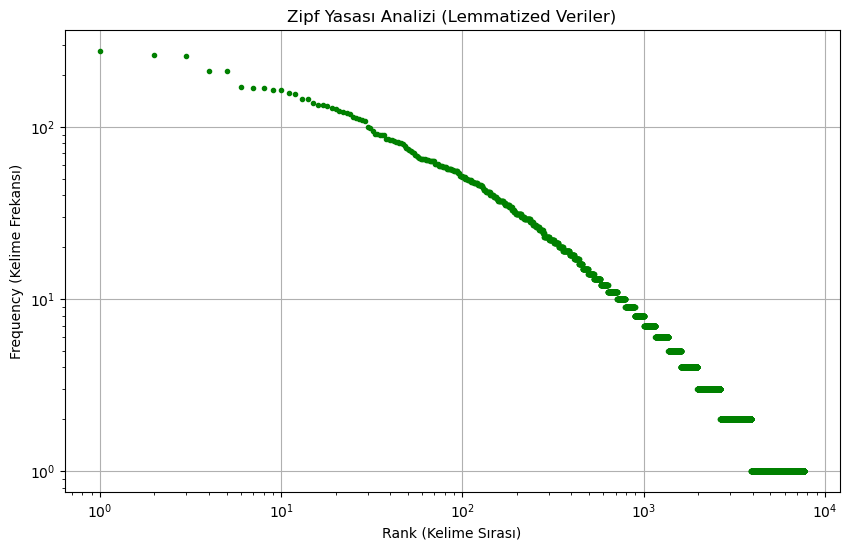

In [85]:
# Lemmatize edilmiş kelimeleri birleştir
lemmatized_tokens = [token for sublist in df_sample['tokens_lemmatized'] for token in sublist]

# Kelime frekanslarını hesapla
lemmatized_counts = Counter(lemmatized_tokens)
sorted_lemmatized = lemmatized_counts.most_common()

# Rank ve frekans çıkar
ranks_lem = np.arange(1, len(sorted_lemmatized) + 1)
frequencies_lem = [count for word, count in sorted_lemmatized]

# Zipf grafiği (Lemmatized)
plt.figure(figsize=(10,6))
plt.loglog(ranks_lem, frequencies_lem, marker='.', linestyle='None', color='green')
plt.title("Zipf Yasası Analizi (Lemmatized Veriler)")
plt.xlabel("Rank (Kelime Sırası)")
plt.ylabel("Frequency (Kelime Frekansı)")
plt.grid(True)
plt.show()


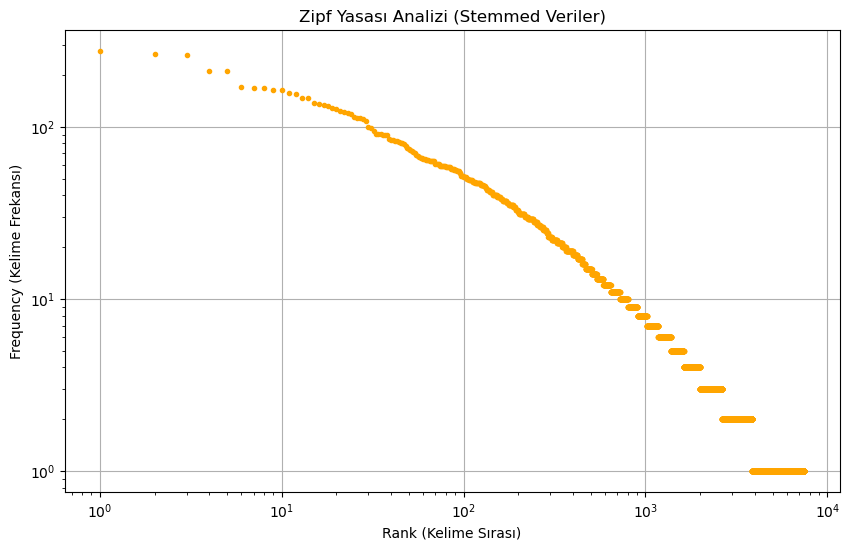

In [87]:
# Stemlenmiş kelimeleri birleştir
stemmed_tokens = [token for sublist in df_sample['tokens_stemmed'] for token in sublist]

# Kelime frekanslarını hesapla
stemmed_counts = Counter(stemmed_tokens)
sorted_stemmed = stemmed_counts.most_common()

# Rank ve frekans çıkar
ranks_stem = np.arange(1, len(sorted_stemmed) + 1)
frequencies_stem = [count for word, count in sorted_stemmed]

# Zipf grafiği (Stemmed)
plt.figure(figsize=(10,6))
plt.loglog(ranks_stem, frequencies_stem, marker='.', linestyle='None', color='orange')
plt.title("Zipf Yasası Analizi (Stemmed Veriler)")
plt.xlabel("Rank (Kelime Sırası)")
plt.ylabel("Frequency (Kelime Frekansı)")
plt.grid(True)
plt.show()


In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Ön işlenmiş token listelerini tekrar metne çeviriyoruz
lemmatized_texts = [' '.join(tokens) for tokens in tokenized_corpus_lemmatized]
lemmatized_texts[:3]

['creamer nabati non dairy creamer premium reguler kg',
 'chek hup ipoh white coffee king x',
 'cod kacamata hitam gaya steampunk vintage bentuk kotak gaya harajuku']

In [91]:
# Şimdi TF-IDF Uygulama Aşamasına Geçiyoruz#


In [93]:
# TF-IDF vektörizerı başlatıyoruz
vectorizer = TfidfVectorizer()
# TF-IDF matrisini oluşturuyoruz
# Terim frekansları, belge frekanslarını hesaplar
# TF-IDF vektörlerine dönüştürür
tfidf_matrix = vectorizer.fit_transform(df_sample['lemmatized_title'])

# Kelimeleri alalım
# TF-IDF vektörleştirme işleminde kullanılan tüm kelimelerin eşsiz bir listesini alalım
feature_names = vectorizer.get_feature_names_out()

# TF-IDF matrisini pandas DataFrame'e çevir - görünürlük açısından
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# İlk birkaç satırı gösterelim - ilk 5 cümle
print(tfidf_df.head())

# Sonuçları bir CSV dosyasına kaydedelim
tfidf_df.to_csv("tfidf_lemmatized.csv", index=False)
print("✅ tfidf_lemmatized.csv dosyası kaydedildi.")


   _benassi  _hajar   aa  aaa  aambar  aarealme   ab  abadi  abang  abaya  \
0       0.0     0.0  0.0  0.0     0.0       0.0  0.0    0.0    0.0    0.0   
1       0.0     0.0  0.0  0.0     0.0       0.0  0.0    0.0    0.0    0.0   
2       0.0     0.0  0.0  0.0     0.0       0.0  0.0    0.0    0.0    0.0   
3       0.0     0.0  0.0  0.0     0.0       0.0  0.0    0.0    0.0    0.0   
4       0.0     0.0  0.0  0.0     0.0       0.0  0.0    0.0    0.0    0.0   

   ...  zumba  zuper  zuperrr  zuriat  zuvia  zuzhu  zva  zwits  zwitsal  \
0  ...    0.0    0.0      0.0     0.0    0.0    0.0  0.0    0.0      0.0   
1  ...    0.0    0.0      0.0     0.0    0.0    0.0  0.0    0.0      0.0   
2  ...    0.0    0.0      0.0     0.0    0.0    0.0  0.0    0.0      0.0   
3  ...    0.0    0.0      0.0     0.0    0.0    0.0  0.0    0.0      0.0   
4  ...    0.0    0.0      0.0     0.0    0.0    0.0  0.0    0.0      0.0   

   zwitsbaby  
0        0.0  
1        0.0  
2        0.0  
3        0.0  
4    

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Metinleri listeye dönüştür
texts = df_sample["lemmatized_title"].astype(str).tolist()

# PorterStemmer ile stemming
stemmer = PorterStemmer()
stemmed_texts = []
for text in texts:
    tokens = word_tokenize(text)                       # Cümleyi kelimelere ayır
    stemmed = [stemmer.stem(token) for token in tokens]  # Her kelimenin kökünü al
    stemmed_texts.append(" ".join(stemmed))            # Yeniden cümle hâline getir

# Şimdi TF-IDF işlemini yaptık
vectorizer_stem = TfidfVectorizer()
tfidf_matrix_stem = vectorizer_stem.fit_transform(stemmed_texts)
feature_names_stem = vectorizer_stem.get_feature_names_out()

# DataFrame'e çevir ve CSV'ye kaydettik
tfidf_df_stem = pd.DataFrame(tfidf_matrix_stem.toarray(), columns=feature_names_stem)
tfidf_df_stem.to_csv("tfidf_stemmed.csv", index=False)

# İlk 5 satırı göster
print(tfidf_df_stem.head())
print("✅ tfidf_stemmed.csv dosyası kaydedildi.")


   _benassi  _hajar   aa  aaa  aambar  aarealm   ab  abadi  abang  abaya  ...  \
0       0.0     0.0  0.0  0.0     0.0      0.0  0.0    0.0    0.0    0.0  ...   
1       0.0     0.0  0.0  0.0     0.0      0.0  0.0    0.0    0.0    0.0  ...   
2       0.0     0.0  0.0  0.0     0.0      0.0  0.0    0.0    0.0    0.0  ...   
3       0.0     0.0  0.0  0.0     0.0      0.0  0.0    0.0    0.0    0.0  ...   
4       0.0     0.0  0.0  0.0     0.0      0.0  0.0    0.0    0.0    0.0  ...   

   zumba  zuper  zuperrr  zuriat  zuvia  zuzhu  zva  zwit  zwitsal  zwitsbabi  
0    0.0    0.0      0.0     0.0    0.0    0.0  0.0   0.0      0.0        0.0  
1    0.0    0.0      0.0     0.0    0.0    0.0  0.0   0.0      0.0        0.0  
2    0.0    0.0      0.0     0.0    0.0    0.0  0.0   0.0      0.0        0.0  
3    0.0    0.0      0.0     0.0    0.0    0.0  0.0   0.0      0.0        0.0  
4    0.0    0.0      0.0     0.0    0.0    0.0  0.0   0.0      0.0        0.0  

[5 rows x 8345 columns]
✅ tfidf_

In [97]:
# df_sample üzerinde 'lemmatized_title' sütununu kullanıyoruz
tfidf = TfidfVectorizer()
df_tfidf = pd.DataFrame(
    tfidf.fit_transform(df_sample["lemmatized_title"].astype(str)).toarray(),
    columns=tfidf.get_feature_names_out()
)

print("İlk cümlede en yüksek TF-IDF skoruna sahip 5 kelime:")
print(df_tfidf.iloc[0].sort_values(ascending=False).head(5))


İlk cümlede en yüksek TF-IDF skoruna sahip 5 kelime:
creamer    0.707915
nabati     0.384131
dairy      0.366481
reguler    0.318657
non        0.270833
Name: 0, dtype: float64


In [99]:
# PorterStemmer nesnesi
stemmer = PorterStemmer()

# Her başlık için stemming uyguladık
def stem_text(text):
    tokens = word_tokenize(str(text))
    stems  = [stemmer.stem(t) for t in tokens]
    return " ".join(stems)

# Yeni sütunu ekledik
df_sample["stemmed_title"] = df_sample["lemmatized_title"].apply(stem_text)


tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df_sample["stemmed_title"].astype(str))
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print("İlk cümlede en yüksek TF-IDF skoruna sahip 5 kelime:")
print(df_tfidf.iloc[0].sort_values(ascending=False).head(5))



İlk cümlede en yüksek TF-IDF skoruna sahip 5 kelime:
creamer    0.710701
nabati     0.385643
dairi      0.367923
regul      0.307338
non        0.271898
Name: 0, dtype: float64


In [101]:
from sklearn.metrics.pairwise import cosine_similarity

vectorizer_stem = TfidfVectorizer()
tfidf_matrix_stem = vectorizer_stem.fit_transform(stemmed_texts)

# 2. Cosine benzerlik matrisi
cosine_sim = cosine_similarity(tfidf_matrix_stem)

# 3. Gruplama işlemi
groups = []
visited = set()
threshold = 0.85

for i in range(len(stemmed_texts)):
    if i in visited:
        continue
    group = [i]
    visited.add(i)
    for j in range(i + 1, len(stemmed_texts)):
        if cosine_sim[i][j] > threshold:
            group.append(j)
            visited.add(j)
    groups.append(group)

# 4. group_id'leri orijinal veriye ekledik
group_ids = [None] * len(stemmed_texts)
for group_id, group in enumerate(groups):
    for idx in group:
        group_ids[idx] = group_id

df_sample = df_sample.iloc[:len(stemmed_texts)].copy()  # dataframe
df_sample["group_id"] = group_ids

# 5. Kontrol
print(df_sample[["cleaned_title", "group_id"]].head(20))


                                                                                         cleaned_title  \
0                                                     creamer nabati non dairy creamer premium reguler   
1                                                                  chek hup ipoh white coffee king r x   
2                           anid cod kacamata hitam kmaya steampunk vintage bentuk kotak gaya harajuku   
3                                                                sapu mini cikrak sebaguna paket hemat   
4                                              sarung tangan iglove touch screen hp android gojek grab   
5                                                                        roll double tape joyko x yard   
6                  sambungan kran air harmonika spray sprinkel jet penghemat air filter water wastafel   
7                                              bluetooth reciver reciver bluetoth transmiter bluetooth   
8                                             

In [102]:
# 1) TF-IDF matrisini df_sample üzerinden yeniden oluşturuyoruz
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_sample["lemmatized_title"].astype(str))
feature_names = vectorizer.get_feature_names_out()

# 2) "creamer" kelimesinin TF-IDF vektörünü al
creamer_index = list(feature_names).index("creamer")          # 'creamer' indeksini bul
creamer_vector = tfidf_matrix[:, creamer_index].toarray()    # o terimin vektörü

# 3) Tüm terimlerin vektörlerini kullanarak sütunlar arası benzerlik hesapladık
#    (tfidf_matrix.T ile sütun bazlı vektörler elde ediyoruz)
similarities = cosine_similarity(tfidf_matrix.T[creamer_index], tfidf_matrix.T).flatten()

# 4) En yüksek 5 benzer terimi al (kendisi de geleceği için 6 alıp ilkini atacağız)
top_idxs = similarities.argsort()[-6:][::-1]
top_idxs = [i for i in top_idxs if i != creamer_index][:5]

# 5) Sonuçları yazdırdık
print("‘creamer’ kelimesine en çok benzeyen 5 kelime:")
for idx in top_idxs:
    print(f"{feature_names[idx]}: {similarities[idx]:.4f}")



‘creamer’ kelimesine en çok benzeyen 5 kelime:
dairy: 0.8389
nabati: 0.5553
sejkt: 0.5443
diary: 0.5443
non: 0.3019


In [105]:
#Word2Vec modeline geçiyoruz#

In [107]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
import os


In [109]:
df = pd.read_csv("train_sample_5000.csv")
texts = df_sample["title"].dropna().astype(str).tolist()  # eksik değer kontrolü

# Tokenize edilmiş cümle listesi
tokenized_texts = [word_tokenize(text.lower()) for text in texts]


In [111]:
# 1) df_sample’dan tokenized corpus’ları oluştur
tokenized_corpus_lemmatized = df_sample["lemmatized_title"] \
    .dropna().astype(str) \
    .apply(lambda t: word_tokenize(t.lower())) \
    .tolist()

tokenized_corpus_stemmed = df_sample["stemmed_title"] \
    .dropna().astype(str) \
    .apply(lambda t: word_tokenize(t.lower())) \
    .tolist()

# 2) Parametre setleri
parameters = [
    {'model_type': 'cbow',     'window': 2, 'vector_size': 100},
    {'model_type': 'skipgram', 'window': 2, 'vector_size': 100},
    {'model_type': 'cbow',     'window': 4, 'vector_size': 100},
    {'model_type': 'skipgram', 'window': 4, 'vector_size': 100},
    {'model_type': 'cbow',     'window': 2, 'vector_size': 300},
    {'model_type': 'skipgram', 'window': 2, 'vector_size': 300},
    {'model_type': 'cbow',     'window': 4, 'vector_size': 300},
    {'model_type': 'skipgram', 'window': 4, 'vector_size': 300}
]

# 3) Model eğitme ve kaydetme fonksiyonu
def train_and_save_model(corpus, params, prefix):
    sg_flag = 1 if params['model_type']=='skipgram' else 0
    model = Word2Vec(
        sentences=corpus,
        vector_size=params['vector_size'],
        window=params['window'],
        min_count=1,
        sg=sg_flag,
        workers=4,
        epochs=10
    )
    fname = f"{prefix}_{params['model_type']}_w{params['window']}_d{params['vector_size']}.model"
    model.save(fname)
    print(f"→ Saved {fname}")

# 4) Eğit ve kaydet
for p in parameters:
    train_and_save_model(tokenized_corpus_lemmatized, p, "lemmatized_model")

for p in parameters:
    train_and_save_model(tokenized_corpus_stemmed,  p, "stemmed_model")


→ Saved lemmatized_model_cbow_w2_d100.model
→ Saved lemmatized_model_skipgram_w2_d100.model
→ Saved lemmatized_model_cbow_w4_d100.model
→ Saved lemmatized_model_skipgram_w4_d100.model
→ Saved lemmatized_model_cbow_w2_d300.model
→ Saved lemmatized_model_skipgram_w2_d300.model
→ Saved lemmatized_model_cbow_w4_d300.model
→ Saved lemmatized_model_skipgram_w4_d300.model
→ Saved stemmed_model_cbow_w2_d100.model
→ Saved stemmed_model_skipgram_w2_d100.model
→ Saved stemmed_model_cbow_w4_d100.model
→ Saved stemmed_model_skipgram_w4_d100.model
→ Saved stemmed_model_cbow_w2_d300.model
→ Saved stemmed_model_skipgram_w2_d300.model
→ Saved stemmed_model_cbow_w4_d300.model
→ Saved stemmed_model_skipgram_w4_d300.model


In [113]:
# Modelleri yükledik
model_1 = Word2Vec.load("lemmatized_model_cbow_w2_d100.model")
model_2 = Word2Vec.load("stemmed_model_skipgram_w4_d100.model")
model_3 = Word2Vec.load("lemmatized_model_skipgram_w4_d300.model")

# Benzer kelimeleri yazdıran fonksiyon
def print_similar_words(model, model_name, keyword='creamer'):
    try:
        similarity = model.wv.most_similar(keyword, topn=3)
        print(f"\n{model_name} Modeli - '{keyword}' ile En Benzer 3 Kelime:")
        for word, score in similarity:
            print(f"Kelime: {word}, Benzerlik Skoru: {score:.4f}")
    except KeyError:
        print(f"\n{model_name} Modeli: '{keyword}' kelimesi modelin kelime dağarcığında bulunamadı.")

# Her model için fonksiyonu çağırdık
print_similar_words(model_1, "Lemmatized CBOW Window 2 Dim 100")
print_similar_words(model_2, "Stemmed Skipgram Window 4 Dim 100")
print_similar_words(model_3, "Lemmatized Skipgram Window 4 Dim 300")



Lemmatized CBOW Window 2 Dim 100 Modeli - 'creamer' ile En Benzer 3 Kelime:
Kelime: usb, Benzerlik Skoru: 0.9773
Kelime: tea, Benzerlik Skoru: 0.9772
Kelime: for, Benzerlik Skoru: 0.9772

Stemmed Skipgram Window 4 Dim 100 Modeli - 'creamer' ile En Benzer 3 Kelime:
Kelime: lakban, Benzerlik Skoru: 0.9950
Kelime: habbatussauda, Benzerlik Skoru: 0.9950
Kelime: mp, Benzerlik Skoru: 0.9946

Lemmatized Skipgram Window 4 Dim 300 Modeli - 'creamer' ile En Benzer 3 Kelime:
Kelime: mp, Benzerlik Skoru: 0.9984
Kelime: asus, Benzerlik Skoru: 0.9984
Kelime: raid, Benzerlik Skoru: 0.9978


In [117]:
#Konu: Ödev-2: Eğitilen Modellerle Metin Benzerliği Hesaplama ve Değerlendirme#

In [119]:
#TF-IDF Benzerliği hesaplama#

In [173]:
import pandas as pd

# Dosyayı yükle
df_sample = pd.read_csv("lemmatized_sentences.csv")

# İlk 5 satırı göster
print(df_sample.head())




                                                        lemmatized_text
0                   creamer nabati non dairy creamer premium reguler kg
1                                     chek hup ipoh white coffee king x
2  cod kacamata hitam gaya steampunk vintage bentuk kotak gaya harajuku
3                                 sapu mini cikrak sebaguna paket hemat
4               sarung tangan iglove touch screen hp android gojek grab


In [31]:
# benzer ilk 5 modeli buluyoruz#
#Cosine Similarity Hesaplıyoruz.#
#lemmatized için#

import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# TF-IDF vektör matrisini yükledik
tfidf_df = pd.read_csv("tfidf_lemmatized.csv")

# Giriş metni veri setindeydi, ilk satırı aldık
query_vector = tfidf_df.iloc[0].values.reshape(1, -1)  # 1D vektörü 2D'ye çevirdik

# Tüm veri setiyle benzerlik hesapladık
similarities = cosine_similarity(query_vector, tfidf_df.values).flatten()

# En benzer 5 sonucu bul (kendisi hariç tutmak için index=0'ı atlayabiliriz )
top_indices = similarities.argsort()[-6:][::-1]  # En yüksekten düşüğe (ilk kendisi olabilir)
top_indices = [i for i in top_indices if i != 0][:5]  # Kendisini çıkarıp, ilk 5 benzeri aldık

# Sonuçları gösterdik
print(" En Benzer 5 Cümle (TF-IDF lemmatized):\n")
for i, idx in enumerate(top_indices):
    print(f"{i+1}. Satır: {idx}")
    print(f"   Skor: {similarities[idx]:.4f}")


 En Benzer 5 Cümle (TF-IDF lemmatized):

1. Satır: 2360
   Skor: 0.8027
2. Satır: 1093
   Skor: 0.5632
3. Satır: 432
   Skor: 0.2091
4. Satır: 713
   Skor: 0.2091
5. Satır: 2157
   Skor: 0.1630


In [39]:
df_sample = pd.read_csv("lemmatized_sentences.csv")  # içerik cümlelerinin olduğu dosya, hangi cümleler olduğunu belirliyoruz.#
for i, idx in enumerate(top_indices):
    print(f"{i+1}. Skor: {similarities[idx]:.4f}")
    print(f"   Metin: {df_sample.iloc[idx]['lemmatized_text']}\n")


1. Skor: 0.8059
   Metin: max creamer non dairy creamer

2. Skor: 0.5654
   Metin: max creamer gram non diary creamer termurah sejkt

3. Skor: 0.1970
   Metin: chilmil reguler

4. Skor: 0.1970
   Metin: chilmil reguler

5. Skor: 0.1526
   Metin: chilschool reguler madu vanila



In [35]:
# 1. TF-IDF (stemmed) matrisini yükledik
tfidf_stemmed_df = pd.read_csv("tfidf_stemmed.csv")

# 2. Giriş metninin TF-IDF vektörünü aldık (örnek: 0. satırda olduğunu varsayıyoruz)
query_vector = tfidf_stemmed_df.iloc[0].values.reshape(1, -1)

# 3. Tüm veri setiyle cosine similarity hesapladık
similarities = cosine_similarity(query_vector, tfidf_stemmed_df.values).flatten()

# 4. En yüksek benzerliğe sahip 5 farklı metni buluyoruz (kendisi hariç)
top_indices = similarities.argsort()[-6:][::-1]  # ilk 6 çünkü biri girişin kendisi
top_indices = [i for i in top_indices if i != 0][:5]  # giriş metnini çıkardık

# 5. Metin karşılıklarını görmek için stemmed.csv'yi yükledik
df_stemmed_texts = pd.read_csv("stemmed_sentences.csv")

# 6. Sonuçları yazdırdık
print(" En Benzer 5 Cümle (TF-IDF stemmed):\n")
for i, idx in enumerate(top_indices):
    print(f"{i+1}. Skor: {similarities[idx]:.4f}")
    print(f"   Metin: {df_stemmed_texts.iloc[idx]['stemmed_text']}\n")  # sütun adı örnektir


 En Benzer 5 Cümle (TF-IDF stemmed):

1. Skor: 0.8059
   Metin: max creamer non dairi creamer

2. Skor: 0.5654
   Metin: max creamer gram non diari creamer termurah sejkt

3. Skor: 0.1970
   Metin: chilmil regul

4. Skor: 0.1970
   Metin: chilmil regul

5. Skor: 0.1526
   Metin: chilschool regul madu vanila



In [127]:
#Word2Vec Benzerliği Hesaplama#

In [137]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity


In [21]:
# Bu fonksiyon bir cümledeki kelimelerin vektörlerini alır ve ortalamasını hesapladık
def get_sentence_vector(model, sentence):
    vectors = []
    for word in sentence.split():
        if word in model.wv:
            vectors.append(model.wv[word])  # kelime modelde varsa vektörünü aldık
    if vectors:
        return np.mean(vectors, axis=0)  # varsa ortalamasını döndürdük
    else:
        return None  # hiç kelime modele uymuyorsa boş yapsın


In [29]:
from gensim.models import Word2Vec
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Giriş metni
query = "creamer nabati non dairy creamer premium reguler kg"

# Tüm model dosyaları
model_files = [
    "lemmatized_model_cbow_w2_d100.model",
    "lemmatized_model_skipgram_w2_d100.model",
    "lemmatized_model_cbow_w4_d100.model",
    "lemmatized_model_skipgram_w4_d100.model",
    "lemmatized_model_cbow_w2_d300.model",
    "lemmatized_model_skipgram_w2_d300.model",
    "lemmatized_model_cbow_w4_d300.model",
    "lemmatized_model_skipgram_w4_d300.model",
    "stemmed_model_cbow_w2_d100.model",
    "stemmed_model_skipgram_w2_d100.model",
    "stemmed_model_cbow_w4_d100.model",
    "stemmed_model_skipgram_w4_d100.model",
    "stemmed_model_cbow_w2_d300.model",
    "stemmed_model_skipgram_w2_d300.model",
    "stemmed_model_cbow_w4_d300.model",
    "stemmed_model_skipgram_w4_d300.model"
]

# Cümleyi vektöre çeviren fonksiyon budur
def get_sentence_vector(model, sentence):
    words = sentence.split()
    word_vecs = []
    for word in words:
        if word in model.wv:
            word_vecs.append(model.wv[word])
    if len(word_vecs) == 0:
        return None
    return np.mean(word_vecs, axis=0)

# Döngüyle her model için işlemi yaptık
for model_path in model_files:
    print("Şu modelde çalışılıyor:", model_path)

    # Modeli yükledik
    model = Word2Vec.load(model_path)

    # Doğru veri dosyasını ve sütunu seçtik
    if "lemmatized" in model_path:
        df_sample = pd.read_csv("lemmatized_sentences.csv")
        text_column = 'lemmatized_text'
    else:
        df_sample = pd.read_csv("stemmed_sentences.csv")
        text_column = 'stemmed_text'

    # Giriş cümlesini vektöre çevirdik
    query_vec = get_sentence_vector(model, query)

    # Hiçbir kelime modelde yoksa uyar
    if query_vec is None:
        print("⚠️ Giriş cümlesi için modelde temsil edilebilecek kelime bulunamadı.\n")
        continue

    # Tüm cümleleri vektöre çevirdik
    sentence_vectors = []
    for text in df_sample[text_column]:
        vec = get_sentence_vector(model, text)
        sentence_vectors.append(vec)

    # Cosine similarity hesapladık
    similarities = []
    for vec in sentence_vectors:
        if vec is not None:
            score = cosine_similarity([query_vec], [vec])[0][0]
        else:
            score = 0
        similarities.append(score)

    # En benzer 5 sonucu bulduk
    top_indices = np.argsort(similarities)[-5:][::-1]

    # Sonuçları yazdırdık
    print(f"\n Model: {model_path}")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. Skor: {similarities[idx]:.4f}")
        print(f"   Metin: {df_sample.iloc[idx][text_column]}\n")


Şu modelde çalışılıyor: lemmatized_model_cbow_w2_d100.model

 Model: lemmatized_model_cbow_w2_d100.model
1. Skor: 1.0000
   Metin: creamer nabati non dairy creamer premium reguler kg

2. Skor: 0.9994
   Metin: miranda hair color premium bleaching

3. Skor: 0.9993
   Metin: bantal ala duduk silikon gel empuk kualitas premium

4. Skor: 0.9993
   Metin: denay premium deesca pink

5. Skor: 0.9993
   Metin: garam himalaya kg pink himsalt original premium

Şu modelde çalışılıyor: lemmatized_model_skipgram_w2_d100.model

 Model: lemmatized_model_skipgram_w2_d100.model
1. Skor: 1.0000
   Metin: creamer nabati non dairy creamer premium reguler kg

2. Skor: 0.9986
   Metin: kit grand prix premium compound ml

3. Skor: 0.9986
   Metin: kail biru mix carbon

4. Skor: 0.9985
   Metin: garam himalaya pink salt gr premium original safiya herbal

5. Skor: 0.9984
   Metin: lakban gold tape tipe biru inch mm coklat high quality

Şu modelde çalışılıyor: lemmatized_model_cbow_w4_d100.model

 Model: lemmat

In [ ]:
#Sıralama Tutarlılığı Değerlendirmesi (Ranking Agreement)
#Jaccard benzerliği hesaplama

In [15]:
from gensim.models import Word2Vec
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import json

# Giriş metni
query = "creamer nabati non dairy creamer premium reguler kg"

# Word2Vec model dosya adları
model_files = [
    "lemmatized_model_cbow_w2_d100.model",
    "lemmatized_model_skipgram_w2_d100.model",
    "lemmatized_model_cbow_w4_d100.model",
    "lemmatized_model_skipgram_w4_d100.model",
    "lemmatized_model_cbow_w2_d300.model",
    "lemmatized_model_skipgram_w2_d300.model",
    "lemmatized_model_cbow_w4_d300.model",
    "lemmatized_model_skipgram_w4_d300.model",
    "stemmed_model_cbow_w2_d100.model",
    "stemmed_model_skipgram_w2_d100.model",
    "stemmed_model_cbow_w4_d100.model",
    "stemmed_model_skipgram_w4_d100.model",
    "stemmed_model_cbow_w2_d300.model",
    "stemmed_model_skipgram_w2_d300.model",
    "stemmed_model_cbow_w4_d300.model",
    "stemmed_model_skipgram_w4_d300.model"
]

# Cümleyi ortalama vektöre çeviren fonksiyon
def get_sentence_vector(model, sentence):
    word_vecs = [model.wv[word] for word in sentence.split() if word in model.wv]
    return np.mean(word_vecs, axis=0) if word_vecs else None

# Tüm sonuçları saklayacağımız sözlük
model_top_indices = {}

# Dosya yolları
df_sample = "lemmatized_sentences.csv"
df_sample = "stemmed_sentences.csv"

# Her model için işlem yap
for model_path in model_files:
    print(f" İşleniyor: {model_path}")

    model = Word2Vec.load(model_path)

    # Veri kümesini yükle
    if "lemmatized" in model_path:
        df_sample = pd.read_csv("lemmatized_sentences.csv")
        text_column = 'lemmatized_text'
    else:
        df_sample = pd.read_csv("stemmed_sentences.csv")
        text_column = 'stemmed_text'

    # Giriş cümlesinin vektörü
    query_vec = get_sentence_vector(model, query)
    if query_vec is None:
        print(f"⚠️ Model '{model_path}' giriş cümlesini temsil edemedi.")
        continue

    # Her satır için ortalama vektör ve benzerlik
    sentence_vectors = [get_sentence_vector(model, text) for text in df_sample[text_column]]
    similarities = [
        cosine_similarity([query_vec], [vec])[0][0] if vec is not None else 0
        for vec in sentence_vectors
    ]

    # En benzer 5 cümleyi bul
    top_indices = np.argsort(similarities)[-5:][::-1]
    model_top_indices[model_path] = top_indices.tolist()

    # İsteğe bağlı: sonuçları terminale yazdır
    print(f"📌 İlk 5 index: {top_indices.tolist()}\n")

# JSON olarak kaydet
with open("model_top_indices.json", "w") as f:
    json.dump(model_top_indices, f, indent=2)

print("✅ Tüm modellerin ilk 5 sonucu 'model_top_indices.json' dosyasına kaydedildi.")


 İşleniyor: lemmatized_model_cbow_w2_d100.model
📌 İlk 5 index: [0, 2903, 704, 4593, 1509]

 İşleniyor: lemmatized_model_skipgram_w2_d100.model
📌 İlk 5 index: [0, 1492, 123, 4642, 4215]

 İşleniyor: lemmatized_model_cbow_w4_d100.model
📌 İlk 5 index: [0, 704, 4724, 1509, 4642]

 İşleniyor: lemmatized_model_skipgram_w4_d100.model
📌 İlk 5 index: [0, 1492, 3406, 4431, 2266]

 İşleniyor: lemmatized_model_cbow_w2_d300.model
📌 İlk 5 index: [0, 1633, 4128, 4211, 704]

 İşleniyor: lemmatized_model_skipgram_w2_d300.model
📌 İlk 5 index: [0, 4211, 4642, 4128, 1509]

 İşleniyor: lemmatized_model_cbow_w4_d300.model
📌 İlk 5 index: [0, 1509, 4518, 4642, 4128]

 İşleniyor: lemmatized_model_skipgram_w4_d300.model
📌 İlk 5 index: [0, 1492, 3406, 4431, 2266]

 İşleniyor: stemmed_model_cbow_w2_d100.model
📌 İlk 5 index: [0, 4128, 4211, 106, 4642]

 İşleniyor: stemmed_model_skipgram_w2_d100.model
📌 İlk 5 index: [0, 1492, 4642, 4211, 1509]

 İşleniyor: stemmed_model_cbow_w4_d100.model
📌 İlk 5 index: [0, 4128, 3

In [ ]:
#Jaccard Benzerlik Matrisi Hesaplama

In [17]:
import json
import pandas as pd

# JSON'dan veriyi oku
with open("model_top_indices.json", "r") as f:
    model_indices = json.load(f)

# Model isimlerini sırayla al
model_names = list(model_indices.keys())

# Boş Jaccard benzerlik matrisini başlat
jaccard_matrix = pd.DataFrame(index=model_names, columns=model_names)

# Jaccard benzerliklerini hesapla
for model_a in model_names:
    set_a = set(model_indices[model_a])
    for model_b in model_names:
        set_b = set(model_indices[model_b])
        intersection = len(set_a & set_b)
        union = len(set_a | set_b)
        jaccard_score = intersection / union if union != 0 else 0
        jaccard_matrix.loc[model_a, model_b] = round(jaccard_score, 2)

# CSV olarak kaydet (rapora eklemek istersen)
jaccard_matrix.to_csv("jaccard_similarity_matrix.csv")

# Yazdır (konsol için)
print(jaccard_matrix)


                                        lemmatized_model_cbow_w2_d100.model  \
lemmatized_model_cbow_w2_d100.model                                     1.0   
lemmatized_model_skipgram_w2_d100.model                                0.11   
lemmatized_model_cbow_w4_d100.model                                    0.43   
lemmatized_model_skipgram_w4_d100.model                                0.11   
lemmatized_model_cbow_w2_d300.model                                    0.25   
lemmatized_model_skipgram_w2_d300.model                                0.25   
lemmatized_model_cbow_w4_d300.model                                    0.25   
lemmatized_model_skipgram_w4_d300.model                                0.11   
stemmed_model_cbow_w2_d100.model                                       0.11   
stemmed_model_skipgram_w2_d100.model                                   0.25   
stemmed_model_cbow_w4_d100.model                                       0.11   
stemmed_model_skipgram_w4_d100.model                